In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


Chase = pd.read_excel('Chase Dataset.xlsx')


Chase.head()


,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,Zipcode,Latitude,Longitude,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,43240,40.14453,-82.99115,633131000.0,743268000.0,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,10583,40.97008,-73.80670,293229.0,310791.0,325742.0,327930.0,3.277920e+05,3.414750e+05,381558
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,11021,40.77944,-73.72240,191011.0,206933.0,216439.0,237983.0,2.341830e+05,2.624550e+05,278940
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,10530,41.02654,-73.79168,87110.0,88367.0,93163.0,109659.0,1.119850e+05,1.167720e+05,140233
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,11559,40.62715,-73.73675,172608.0,172749.0,189413.0,198445.0,2.051980e+05,2.232000e+05,235594


Identifying the Data Types, here we're identifying what to standardize proper Data Types

In [160]:
Chase.info()

<class 'pandas.DataFrame'>
RangeIndex: 5413 entries, 0 to 5412
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Institution Name  5413 non-null   str    
 1   Main Office       5413 non-null   int64  
 2   Branch Name       5413 non-null   str    
 3   Branch Number     5413 non-null   int64  
 4   Established Date  5413 non-null   object 
 5   Acquired Date     3798 non-null   object 
 6   Street Address    5413 non-null   str    
 7   City              5413 non-null   str    
 8   County            5413 non-null   str    
 9   State             5413 non-null   str    
 10  Zipcode           5413 non-null   int64  
 11  Latitude          5347 non-null   float64
 12  Longitude         5347 non-null   float64
 13  2010 Deposits     4673 non-null   float64
 14  2011 Deposits     4835 non-null   float64
 15  2012 Deposits     5084 non-null   float64
 16  2013 Deposits     5238 non-null   float64
 17  2014 D

In [161]:
Chase.dropna(inplace=True)
Chase.drop_duplicates(inplace=True)
Chase.duplicated().sum()

np.int64(0)

In [162]:
Chase['Acquired Date'] = Chase['Acquired Date'].fillna(0)

Entries(Rows), Columns

In [163]:
Chase.shape

(3784, 20)

Defining a funstion that allows to Drop/clean the blanks and duplicates from the dataset 

In [164]:
def cleand_data(Chase):
    Chase.dropna(inplace=True)

    Chase.drop_duplicates(inplace=True)

    return Chase

Chase = cleand_data(Chase)
Chase.info()

<class 'pandas.DataFrame'>
Index: 3784 entries, 72 to 4483
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Institution Name  3784 non-null   str    
 1   Main Office       3784 non-null   int64  
 2   Branch Name       3784 non-null   str    
 3   Branch Number     3784 non-null   int64  
 4   Established Date  3784 non-null   object 
 5   Acquired Date     3784 non-null   object 
 6   Street Address    3784 non-null   str    
 7   City              3784 non-null   str    
 8   County            3784 non-null   str    
 9   State             3784 non-null   str    
 10  Zipcode           3784 non-null   int64  
 11  Latitude          3784 non-null   float64
 12  Longitude         3784 non-null   float64
 13  2010 Deposits     3784 non-null   float64
 14  2011 Deposits     3784 non-null   float64
 15  2012 Deposits     3784 non-null   float64
 16  2013 Deposits     3784 non-null   float64
 17  2014 Depos

Converting some of the fields with their proper Data types:

Established Date → datetime
Acquired Date → datetime

These are repeating labels → better as category:
Institution Name,
Branch Name,
City,
County,
State

In [165]:
def convert_data(Chase):
    Chase['Established Date'] = pd.to_datetime(Chase['Established Date'], errors='coerce')
    Chase['Acquired Date'] = pd.to_datetime(Chase['Acquired Date'], errors='coerce')
    col = ['Institution Name', 'Branch Name', 'City', 'County', 'State']
    for col in col:
        Chase[col] = Chase[col].astype('category')
    return Chase

Chase = convert_data(Chase)
Chase.info()

<class 'pandas.DataFrame'>
Index: 3784 entries, 72 to 4483
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Institution Name  3784 non-null   category      
 1   Main Office       3784 non-null   int64         
 2   Branch Name       3784 non-null   category      
 3   Branch Number     3784 non-null   int64         
 4   Established Date  3784 non-null   datetime64[us]
 5   Acquired Date     3784 non-null   datetime64[us]
 6   Street Address    3784 non-null   str           
 7   City              3784 non-null   category      
 8   County            3784 non-null   category      
 9   State             3784 non-null   category      
 10  Zipcode           3784 non-null   int64         
 11  Latitude          3784 non-null   float64       
 12  Longitude         3784 non-null   float64       
 13  2010 Deposits     3784 non-null   float64       
 14  2011 Deposits     3784 non-null   float

View

In [166]:
#Branch Age (from Established Date)
Chase = Chase['Branch_Age'] = 2016 - Chase['Established Date'].dt.year
Chase.head()

72    62
73    61
74    61
75    51
76    66
Name: Established Date, dtype: object

In [167]:
#Years Since Acquisition (from Acquired Date)
# Replace cell 11
# Branch Age (from Established Date)
# ensure Chase is a DataFrame (recover if accidentally set to Ellipsis)
if not isinstance(Chase, pd.DataFrame):
    Chase = pd.read_excel('Chase Dataset.xlsx')

# Branch age and years since acquisition (safe datetime parsing)
Chase['Branch_Age'] = 2016 - pd.to_datetime(Chase['Established Date'], errors='coerce').dt.year
Chase['Years_Since_Acquisition'] = 2016 - pd.to_datetime(Chase['Acquired Date'], errors='coerce').dt.year
Chase.head()
#Hindle Nulls
Chase['Years_Since_Acquisition'] = Chase['Years_Since_Acquisition'].fillna(0)
Chase.head()   

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,Longitude,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,...,-82.99115,633131000.0,743268000.0,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000,192,0.0
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,...,-73.80670,293229.0,310791.0,325742.0,327930.0,3.277920e+05,3.414750e+05,381558,55,0.0
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,...,-73.72240,191011.0,206933.0,216439.0,237983.0,2.341830e+05,2.624550e+05,278940,53,0.0
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,...,-73.79168,87110.0,88367.0,93163.0,109659.0,1.119850e+05,1.167720e+05,140233,50,0.0
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,...,-73.73675,172608.0,172749.0,189413.0,198445.0,2.051980e+05,2.232000e+05,235594,51,0.0


In [168]:
#Total Deposits (2010–2016)
deposit_cols = [col for col in Chase.columns if 'Deposits' in col]
Chase['Total_Deposits'] = Chase[deposit_cols].sum(axis=1)
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2010 Deposits,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,...,633131000.0,743268000.0,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000,192,0.0,6.382556e+09
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,...,293229.0,310791.0,325742.0,327930.0,3.277920e+05,3.414750e+05,381558,55,0.0,2.308517e+06
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,...,191011.0,206933.0,216439.0,237983.0,2.341830e+05,2.624550e+05,278940,53,0.0,1.627944e+06
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,...,87110.0,88367.0,93163.0,109659.0,1.119850e+05,1.167720e+05,140233,50,0.0,7.472890e+05
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,...,172608.0,172749.0,189413.0,198445.0,2.051980e+05,2.232000e+05,235594,51,0.0,1.397207e+06


In [169]:
#Growth % (2010 → 2016)
Chase['Growth_%'] = ((Chase['2016 Deposits'] - Chase['2010 Deposits']) / Chase['2010 Deposits']) * 100
#AVoied division by zero
Chase = Chase[Chase['2010 Deposits'] > 0]
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2011 Deposits,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits,Growth_%
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,...,743268000.0,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000,192,0.0,6.382556e+09,82.455921
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,...,310791.0,325742.0,327930.0,3.277920e+05,3.414750e+05,381558,55,0.0,2.308517e+06,30.122873
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,...,206933.0,216439.0,237983.0,2.341830e+05,2.624550e+05,278940,53,0.0,1.627944e+06,46.033475
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,...,88367.0,93163.0,109659.0,1.119850e+05,1.167720e+05,140233,50,0.0,7.472890e+05,60.983814
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,...,172749.0,189413.0,198445.0,2.051980e+05,2.232000e+05,235594,51,0.0,1.397207e+06,36.490777


In [170]:
#CAGR (Advanced but powerful)
Chase['CAGR'] = ((Chase['2016 Deposits'] / Chase['2010 Deposits']) ** (1/6)) - 1
Chase.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch_Age,Years_Since_Acquisition,Total_Deposits,Growth_%,CAGR
0,JPMorgan Chase Bank,1,JPMorgan Chase Bank Main Office,0,01/01/1824,NaN,1111 Polaris Parkway,Columbus,Delaware,OH,...,832455000.0,916543000.0,1.032549e+09,1.069425e+09,1155185000,192,0.0,6.382556e+09,82.455921,0.105417
1,JPMorgan Chase Bank,0,Vernon Hills Scarsdale Branch,2,03/20/1961,NaN,676 White Plains Road,Scarsdale,Westchester,NY,...,325742.0,327930.0,3.277920e+05,3.414750e+05,381558,55,0.0,2.308517e+06,30.122873,0.044862
2,JPMorgan Chase Bank,0,Great Neck Northern Boulevard Branch,3,1963-09-09 00:00:00,NaN,410 Northern Boulevard,Great Neck,Nassau,NY,...,216439.0,237983.0,2.341830e+05,2.624550e+05,278940,53,0.0,1.627944e+06,46.033475,0.065145
3,JPMorgan Chase Bank,0,North Hartsdale Branch,4,02/19/1966,NaN,353 North Central Avenue,Hartsdale,Westchester,NY,...,93163.0,109659.0,1.119850e+05,1.167720e+05,140233,50,0.0,7.472890e+05,60.983814,0.082589
4,JPMorgan Chase Bank,0,Lawrence Rockaway Branch,5,01/16/1965,NaN,335 Rockaway Turnpike,Lawrence,Nassau,NY,...,189413.0,198445.0,2.051980e+05,2.232000e+05,235594,51,0.0,1.397207e+06,36.490777,0.053215



answer real business questions.


A. Institution-Level Analysis


Who dominates deposits?


Who is growing fastest?



In [171]:
inst_summary = Chase.groupby('Institution Name').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
}).sort_values(by='Total_Deposits', ascending=False)
inst_summary.head()

,Total_Deposits,Growth_%
Institution Name,,
JPMorgan Chase Bank,1.252341e+10,152.496434


B. Branch-Level Performance


Which Branch Name / Branch Number are top vs weak?

In [172]:
top_branches = Chase.sort_values(by='Total_Deposits', ascending=False).head(10)
low_branches = Chase.sort_values(by='Total_Deposits', ascending=True).head(10)
top_branches[['Branch Name', 'Total_Deposits']]
low_branches[['Branch Name', 'Total_Deposits']]


,Branch Name,Total_Deposits
738,Dayton Downtown Drive-Up Branch,1.0
264,Select Direct I Branch,1032.0
1708,Noble Jackson Branch,4909.0
1743,Richmond Motor Bank Branch,8208.0
720,North Sidney Branch,13015.0
1217,International Private Bkg Ctr Branch,20355.0
372,Select Direct II Branch,25511.0
897,Woodfield Facility Branch,25622.0
4262,Englewood Plaza Branch,26901.0
4631,Prescott Valley Frys Bnkg Ctr Branch,31039.0


C. Geographic Analysis

Which states = strong markets


Which states = declining

In [173]:
state_summary = Chase.groupby('State').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
}).sort_values(by='Total_Deposits', ascending=False)
state_summary.head()

,Total_Deposits,Growth_%
State,,
OH,6.540037e+09,78.822827
NY,2.871412e+09,105.992572
TX,8.623496e+08,158.130358
CA,5.554652e+08,277.461678
IL,4.990470e+08,253.659438


D. Trend Over Time

In [174]:
yearly_totals = Chase[deposit_cols].sum()
yearly_totals.head()

2010 Deposits    1.247063e+09
2011 Deposits    1.462278e+09
2012 Deposits    1.632782e+09
2013 Deposits    1.795223e+09
2014 Deposits    2.023020e+09
dtype: float64

E. Risk Detection

In [175]:
declining = Chase[Chase ['Growth_%'] < 0]
declining[['Branch Name', 'Growth_%']].head(10)


,Branch Name,Growth_%
104,Yankee Stadium Branch,-96.507216
202,Madison Avenue and 64th St Branch,-93.255613
205,First Ave and 44th St Branch,-45.106132
264,Select Direct I Branch,-4.848485
344,Madison Waverly Branch,-10.896537
372,Select Direct II Branch,-10.302382
429,Mcallen Neuhaus Tower Branch,-1.947553
483,El Paso - Downtown Branch,-3.659527
564,Newark Main Branch,-10.894543
613,Karamu Branch,-1.980418


VISUALIZATION 

Deposit Trend Over Time

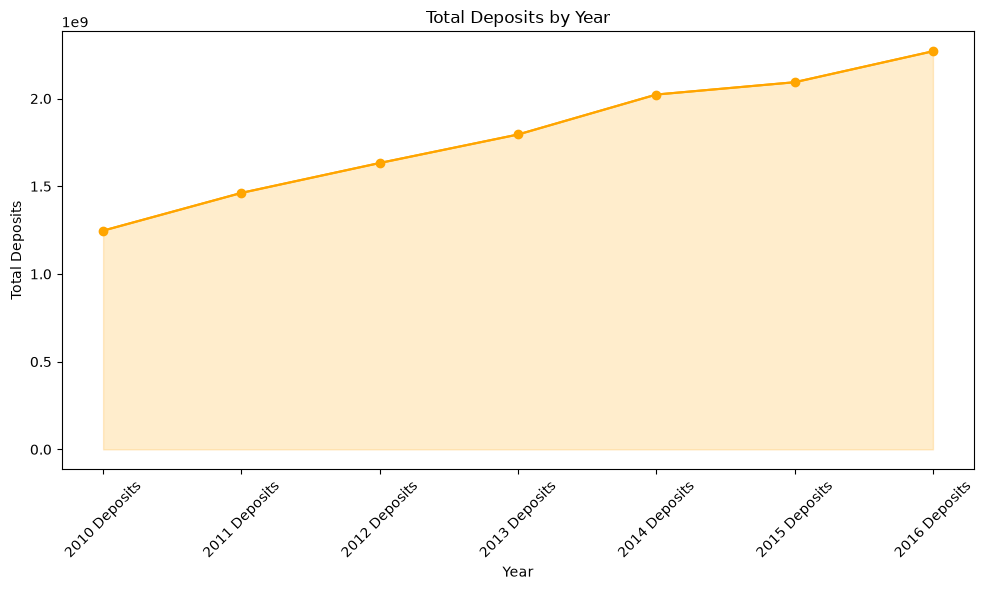

In [176]:
yearly_totals.plot(kind='line', figsize=(10,6), title='Total Deposits by Year', color='Orange')
plt.xlabel('Year')  
plt.plot(yearly_totals.index, yearly_totals.values, marker='o', color='Orange')
plt.fill_between(yearly_totals.index, yearly_totals.values, alpha=0.2, color='Orange')
plt.ylabel('Total Deposits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top Branches (Performance Ranking)

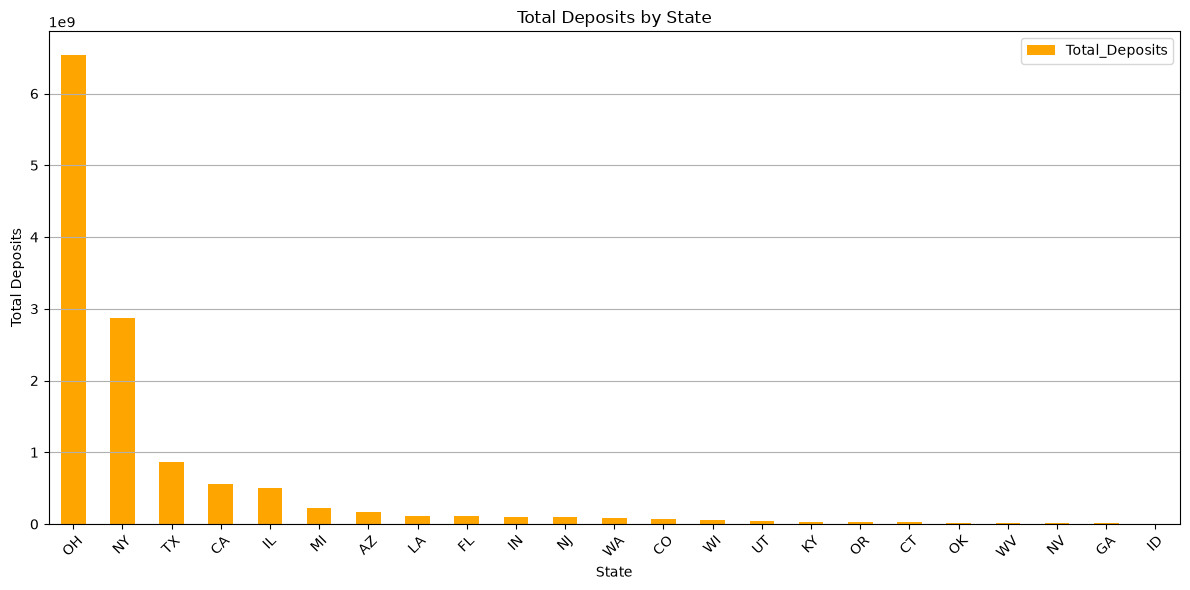

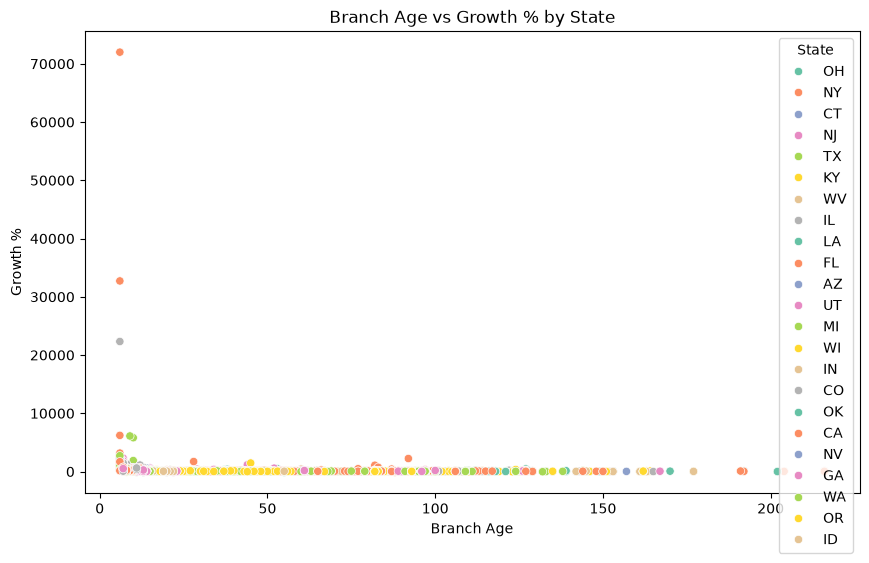

In [177]:
state_summary.plot(kind='bar', y='Total_Deposits', figsize=(12,6), title='Total Deposits by State', color='Orange')
plt.xlabel('State')
plt.ylabel('Total Deposits')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,6))
sns.scatterplot(data=Chase, x='Branch_Age', y='Growth_%', hue='State', palette='Set2')
plt.title('Branch Age vs Growth % by State')
plt.xlabel('Branch Age')
plt.ylabel('Growth %')
plt.legend(title='State')
plt.show()

Growth % Distribution

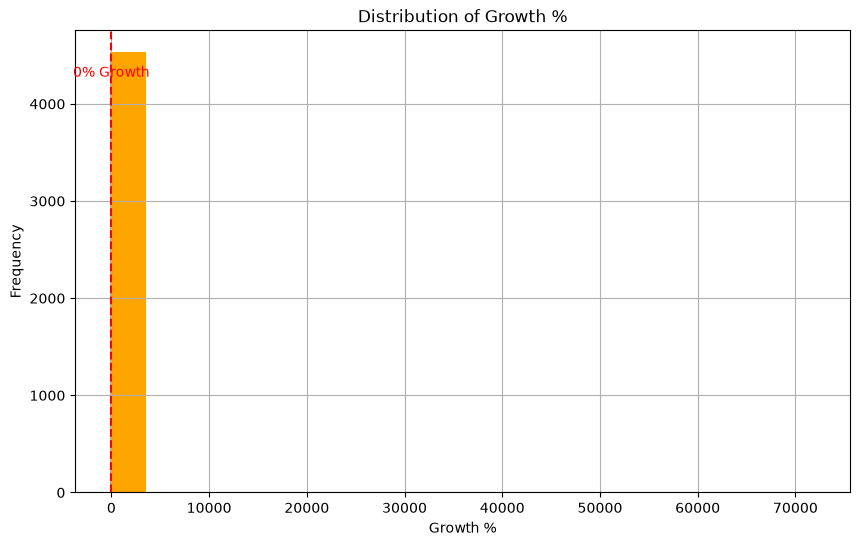

In [178]:
Chase["Growth_%"].plot(kind='hist', bins=20, figsize=(10,6), title='Distribution of Growth %', color='Orange')
plt.xlabel('Growth %')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')  # Add a vertical line at 0% growth
plt.text(0, plt.ylim()[1]*0.9, '0% Growth', color='red', fontsize=10, ha='center')  # Add text label
plt.grid()
plt.show()


In [179]:
print(Chase.columns)

Index(['Institution Name', 'Main Office', 'Branch Name', 'Branch Number',
       'Established Date', 'Acquired Date', 'Street Address', 'City', 'County',
       'State', 'Zipcode', 'Latitude', 'Longitude', '2010 Deposits',
       '2011 Deposits', '2012 Deposits', '2013 Deposits', '2014 Deposits',
       '2015 Deposits', '2016 Deposits', 'Branch_Age',
       'Years_Since_Acquisition', 'Total_Deposits', 'Growth_%', 'CAGR'],
      dtype='str')


In [180]:
Chase.dropna(inplace=True)
Chase.isnull().sum()

Institution Name           0
Main Office                0
Branch Name                0
Branch Number              0
Established Date           0
Acquired Date              0
Street Address             0
City                       0
County                     0
State                      0
Zipcode                    0
Latitude                   0
Longitude                  0
2010 Deposits              0
2011 Deposits              0
2012 Deposits              0
2013 Deposits              0
2014 Deposits              0
2015 Deposits              0
2016 Deposits              0
Branch_Age                 0
Years_Since_Acquisition    0
Total_Deposits             0
Growth_%                   0
CAGR                       0
dtype: int64

In [158]:
print(Chase['Acquired Date'])

72      01/18/1975
73      01/18/1975
74      01/18/1975
75      01/18/1975
76      01/18/1975
           ...    
4349    09/25/2008
4350    09/25/2008
4351    09/25/2008
4482    09/25/2008
4483    09/25/2008
Name: Acquired Date, Length: 3674, dtype: object


Matthew Ferrer